# Development pseudo-OOS: M0–M5b

Follow the frozen [forecasting protocol](../docs/forecasts.md) for the two five-SPX-session targets. M0–M2 are the unchanged baseline; M3 adds own dynamics, M4 adds the declared surface block, M5a adds realised market state, and M5b adds VIX. This notebook uses development dates only (2023–2024), with expanding fits and the mandatory $i+5\leq t$ label-maturity rule. The 2025 confirmation period remains locked. Five-session outcomes overlap; no iid significance claim is made here.

## Development sample and feature coverage

Load QC-approved option metrics and the SPX/VIX price extracts, excluding 2025 rows before feature construction. SPX sessions remain the calendar; market state is joined on exact dates with no filling. Earlier SPX observations can warm up realised volatility. The final five development outcomes remain unavailable.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from src.forecasting import (
    ALL_MODELS, DEV_END, LINEAR_MODELS, build_linear_development_dataset,
    forecast_linear_development, score_linear_development_forecasts,
)
from src.time_series import load_skew_metrics

metrics = load_skew_metrics(project_root / 'data/processed/spx_skew_metrics_2023_2025.csv')
metrics = metrics.loc[metrics['quote_date'] <= DEV_END].copy()
spx_prices = pd.read_csv(project_root / 'data/raw/spx_security_prices.csv')
spx_prices = spx_prices.loc[pd.to_datetime(spx_prices['date']) <= DEV_END].copy()
vix_prices = pd.read_csv(project_root / 'data/raw/VIX_security_prices.csv')
vix_prices = vix_prices.loc[pd.to_datetime(vix_prices['date']) <= DEV_END].copy()
development = build_linear_development_dataset(metrics, spx_prices, vix_prices)
display(pd.Series({
    'development sessions': len(development),
    'first session': development['quote_date'].min().date(),
    'last session': development['quote_date'].max().date(),
    'final five labels unavailable': development[[
        'y_skew_30_5d', 'y_skew_spread_5d'
    ]].tail(5).isna().all().all(),
}))
display(development[[
    'z_skew_30', 'z_skew_30_60', 'd_skew_30', 'd_skew_30_60',
    'skew_60', 'skew_30_60', 'skew_60_90',
    'atm_iv_30', 'atm_iv_30_60', 'atm_iv_60_90',
    'spx_return', 'spx_abs_return', 'spx_return_sq', 'rv_5', 'rv_20',
    'vix_close',
]].notna().sum().rename('valid development sessions'))

development sessions                    502
first session                    2023-01-03
last session                     2024-12-31
final five labels unavailable          True
dtype: object

z_skew_30         441
z_skew_30_60      438
d_skew_30         499
d_skew_30_60      493
skew_60           499
skew_30_60        498
skew_60_90        490
atm_iv_30         502
atm_iv_30_60      499
atm_iv_60_90      490
spx_return        502
spx_abs_return    502
spx_return_sq     502
rv_5              502
rv_20             502
vix_close         502
Name: valid development sessions, dtype: int64

## Strict common-date comparison

Each model is fit on its own declared complete-case, matured training rows. The headline score set then requires a realised target and valid forecasts from **all seven** models on the same origin date. Coverage is shown separately. $R^2_{\mathrm{OOS,persist}}=1-\mathrm{SSE}/\mathrm{SSE}_{M0}$, while for M3–M5b $R^2_{\mathrm{OOS,MR}}=1-\mathrm{SSE}/\mathrm{SSE}_{M2}$. M0 has no defined forecast/realised correlation or directional accuracy.

In [2]:
targets = {
    '30D skew change': 'y_skew_30_5d',
    '30D–60D spread change': 'y_skew_spread_5d',
}
results = {
    name: forecast_linear_development(development, spx_prices, target)
    for name, target in targets.items()
}
scored = {name: score_linear_development_forecasts(results[name][0])
          for name in targets}
coverage = pd.DataFrame([
    {'target': name, 'model': model, 'origins': len(results[name][0]),
     'realised_origins': int(results[name][0]['actual'].notna().sum()),
     'model_forecasts': int(results[name][0][model].notna().sum()),
     'individually_scorable': int(results[name][0][['actual', model]].notna().all(axis=1).sum()),
     'strict_common': len(scored[name][1])}
    for name in targets for model in ALL_MODELS
])
display(coverage)
summary = pd.concat(
    {name: scored[name][0] for name in targets}, names=['target']
).reset_index(level=0)
numeric_columns = summary.select_dtypes(include='number').columns
summary[numeric_columns] = summary[numeric_columns].round(4)
display(summary)

,target,model,origins,realised_origins,model_forecasts,individually_scorable,strict_common
0,30D skew change,m0_persistence,250,245,250,245,238
1,30D skew change,m1_mean,250,245,250,245,238
2,30D skew change,m2_mean_reversion,250,245,250,245,238
3,30D skew change,m3_own_dynamics,250,245,250,245,238
4,30D skew change,m4_surface_state,250,245,243,238,238
5,30D skew change,m5a_realized_state,250,245,243,238,238
6,30D skew change,m5b_vix_state,250,245,243,238,238
7,30D–60D spread change,m0_persistence,250,245,250,245,238
8,30D–60D spread change,m1_mean,250,245,250,245,238
9,30D–60D spread change,m2_mean_reversion,250,245,250,245,238


,target,model,n_common,first_date,last_date,rmse,mae,r2_vs_persistence,r2_vs_mean_reversion,correlation,directional_accuracy
0,30D skew change,m0_persistence,238,2024-01-04,2024-12-23,0.1100,0.0830,0.0000,NaN,NaN,NaN
1,30D skew change,m1_mean,238,2024-01-04,2024-12-23,0.1105,0.0832,-0.0104,NaN,-0.5320,0.5546
2,30D skew change,m2_mean_reversion,238,2024-01-04,2024-12-23,0.0987,0.0752,0.1942,NaN,0.4585,0.6176
3,30D skew change,m3_own_dynamics,238,2024-01-04,2024-12-23,0.0998,0.0761,0.1771,-0.0213,0.4331,0.6303
4,30D skew change,m4_surface_state,238,2024-01-04,2024-12-23,0.0968,0.0763,0.2260,0.0394,0.4931,0.6387
5,30D skew change,m5a_realized_state,238,2024-01-04,2024-12-23,0.1000,0.0789,0.1738,-0.0253,0.4463,0.6050
6,30D skew change,m5b_vix_state,238,2024-01-04,2024-12-23,0.1010,0.0799,0.1563,-0.0471,0.4382,0.5882
0,30D–60D spread change,m0_persistence,238,2024-01-04,2024-12-23,0.0619,0.0465,0.0000,NaN,NaN,NaN
1,30D–60D spread change,m1_mean,238,2024-01-04,2024-12-23,0.0622,0.0467,-0.0096,NaN,-0.5365,0.4874
2,30D–60D spread change,m2_mean_reversion,238,2024-01-04,2024-12-23,0.0524,0.0404,0.2820,NaN,0.5494,0.6597


## Cumulative squared-error gains

Left: M2–M5b versus persistence. Right: M3–M5b versus the simple mean-reversion benchmark. Every line within a target uses the same strict common dates. A broadly rising line is more persuasive than a final gain from one isolated episode; the plot is descriptive, not a significance test.

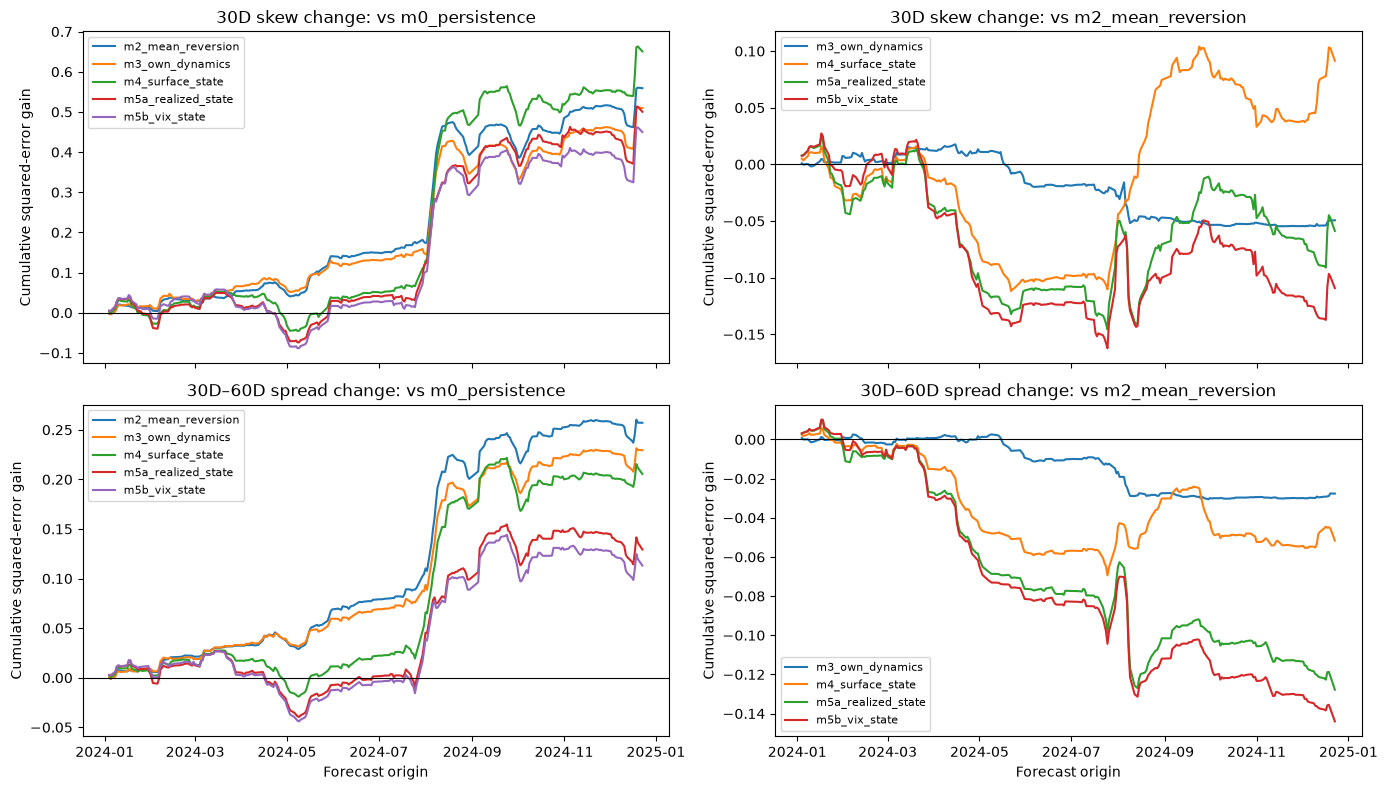

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex='col')
for row, (name, (_, common)) in enumerate(scored.items()):
    actual = common['actual']
    for column, (benchmark, models) in enumerate((
        ('m0_persistence', ('m2_mean_reversion', *LINEAR_MODELS)),
        ('m2_mean_reversion', LINEAR_MODELS),
    )):
        ax = axes[row, column]
        benchmark_error = (actual - common[benchmark]) ** 2
        for model in models:
            gain = benchmark_error - (actual - common[model]) ** 2
            ax.plot(common['quote_date'], gain.cumsum(), label=model)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(f'{name}: vs {benchmark}')
        ax.set_ylabel('Cumulative squared-error gain')
        ax.legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('Forecast origin')
fig.tight_layout()
plt.show()

### Where do incremental gains arise?

Quarterly squared-error gains versus M2 on the same common dates help distinguish broad improvement from one concentrated episode. These are descriptive breakdowns, not new model-selection periods.

In [4]:
quarterly_gains = []
for name, (_, common) in scored.items():
    base_error = (common['actual'] - common['m2_mean_reversion']) ** 2
    for model in LINEAR_MODELS:
        gain = base_error - (common['actual'] - common[model]) ** 2
        by_quarter = gain.groupby(common['quote_date'].dt.to_period('Q')).sum()
        quarterly_gains.extend(
            {'target': name, 'model': model, 'quarter': str(quarter), 'gain_vs_m2': value}
            for quarter, value in by_quarter.items()
        )
display(pd.DataFrame(quarterly_gains).pivot(
    index=['target', 'model'], columns='quarter', values='gain_vs_m2'
).round(4))

quarter                                   2024Q1  2024Q2  2024Q3  2024Q4
target                model                                             
30D skew change       m3_own_dynamics     0.0125 -0.0309 -0.0350  0.0041
                      m4_surface_state   -0.0114 -0.0865  0.1898 -0.0005
                      m5a_realized_state -0.0342 -0.0737  0.0971 -0.0480
                      m5b_vix_state      -0.0380 -0.0838  0.0711 -0.0585
30D–60D spread change m3_own_dynamics     0.0007 -0.0108 -0.0204  0.0029
                      m4_surface_state   -0.0151 -0.0419  0.0156 -0.0102
                      m5a_realized_state -0.0267 -0.0506 -0.0210 -0.0295
                      m5b_vix_state      -0.0291 -0.0536 -0.0292 -0.0321

## Five non-overlapping offsets

Split the strict common-date set by the original SPX `session_index % 5`, without renumbering missing observations. Compare RMSE for M0 and M2–M5b on every fixed offset; no offset is selected.

In [5]:
offset_rows = []
for name, (_, common) in scored.items():
    for offset in range(5):
        subset = common.loc[common['session_index'].mod(5).eq(offset)]
        row = {'target': name, 'offset': offset, 'n': len(subset)}
        for model in ('m0_persistence', 'm2_mean_reversion', *LINEAR_MODELS):
            row[model] = np.sqrt(np.mean((subset['actual'] - subset[model]) ** 2))
        offset_rows.append(row)
display(pd.DataFrame(offset_rows).round(4))

,target,offset,n,m0_persistence,m2_mean_reversion,m3_own_dynamics,m4_surface_state,m5a_realized_state,m5b_vix_state
0,30D skew change,0,47,0.1117,0.1019,0.1023,0.0978,0.0970,0.0983
1,30D skew change,1,48,0.1074,0.0981,0.1000,0.0988,0.1076,0.1085
2,30D skew change,2,49,0.0968,0.0901,0.0920,0.0886,0.0891,0.0901
3,30D skew change,3,46,0.1188,0.0977,0.0961,0.0960,0.0998,0.0992
4,30D skew change,4,48,0.1146,0.1054,0.1077,0.1023,0.1054,0.1079
5,30D–60D spread change,0,47,0.0574,0.0510,0.0507,0.0503,0.0514,0.0520
6,30D–60D spread change,1,48,0.0674,0.0571,0.0582,0.0601,0.0653,0.0657
7,30D–60D spread change,2,49,0.0605,0.0520,0.0537,0.0544,0.0581,0.0586
8,30D–60D spread change,3,46,0.0596,0.0452,0.0466,0.0499,0.0525,0.0529
9,30D–60D spread change,4,48,0.0638,0.0557,0.0573,0.0566,0.0580,0.0589


## OLS coefficient stability

Every fitted M3–M5b coefficient is retained at each forecast origin, whether or not the current predictor vector allows a forecast. For each target, the first table shows the end-development coefficient vector; the second shows the fraction of fitted origins where each coefficient's sign matches its final sign. Magnitudes across raw-scale features are not directly comparable. Instability is diagnosed, not used to alter the frozen specification.

In [6]:
for name, (_, coefficients) in results.items():
    print(name)
    final = coefficients.sort_values('session_index').drop_duplicates(
        ['model', 'feature'], keep='last'
    ).set_index(['model', 'feature'])['coefficient']
    history = coefficients.join(final.rename('final_coefficient'), on=['model', 'feature'])
    history['same_final_sign'] = (
        np.sign(history['coefficient']) == np.sign(history['final_coefficient'])
    )
    sign_stability = history.groupby(['model', 'feature'])['same_final_sign'].mean()
    display(pd.Series({
        model: coefficients.loc[coefficients.model.eq(model), 'session_index'].nunique()
        for model in LINEAR_MODELS
    }, name='fitted origins'))
    display(final.unstack('model').round(4))
    display(sign_stability.unstack('model').round(2))

30D skew change


m3_own_dynamics       250
m4_surface_state      250
m5a_realized_state    250
m5b_vix_state         250
Name: fitted origins, dtype: int64

model,m3_own_dynamics,m4_surface_state,m5a_realized_state,m5b_vix_state
feature,,,,
atm_iv_30,NaN,0.0640,0.0104,-0.4324
atm_iv_30_60,NaN,-3.1092,-2.7322,-2.7210
atm_iv_60_90,NaN,-2.9893,-1.9081,-2.0553
d_skew_30,-0.0917,-0.0201,0.1219,0.1217
intercept,0.0072,0.4519,0.4085,0.4137
rv_20,NaN,NaN,0.2203,0.2298
rv_5,NaN,NaN,-0.0781,-0.0913
skew_30_60,NaN,-1.8776,-1.8436,-1.8742
skew_60,NaN,-0.5764,-0.4959,-0.5178


model,m3_own_dynamics,m4_surface_state,m5a_realized_state,m5b_vix_state
feature,,,,
atm_iv_30,NaN,0.40,0.34,0.22
atm_iv_30_60,NaN,0.61,0.57,0.60
atm_iv_60_90,NaN,0.67,0.33,0.32
d_skew_30,1.00,0.61,1.00,1.00
intercept,0.49,1.00,1.00,1.00
rv_20,NaN,NaN,0.78,0.78
rv_5,NaN,NaN,0.32,0.27
skew_30_60,NaN,1.00,1.00,1.00
skew_60,NaN,1.00,1.00,0.99


30D–60D spread change


m3_own_dynamics       250
m4_surface_state      250
m5a_realized_state    250
m5b_vix_state         250
Name: fitted origins, dtype: int64

model,m3_own_dynamics,m4_surface_state,m5a_realized_state,m5b_vix_state
feature,,,,
atm_iv_30,NaN,-0.0277,-0.0529,-0.3935
atm_iv_30_60,NaN,-1.1651,-1.0082,-0.9846
atm_iv_60_90,NaN,-1.2443,-0.7451,-0.8509
d_skew_30_60,-0.1036,-0.0168,0.0428,0.0379
intercept,0.0048,0.0058,-0.0054,-0.0037
rv_20,NaN,NaN,0.1026,0.1106
rv_5,NaN,NaN,-0.0561,-0.0655
skew_30_60,NaN,-1.9230,-1.9138,-1.9732
skew_60,NaN,0.3512,0.3726,0.3708


model,m3_own_dynamics,m4_surface_state,m5a_realized_state,m5b_vix_state
feature,,,,
atm_iv_30,NaN,0.94,1.00,0.54
atm_iv_30_60,NaN,0.40,0.28,0.28
atm_iv_60_90,NaN,0.43,0.18,0.18
d_skew_30_60,1.00,0.82,0.41,0.41
intercept,0.53,1.00,0.02,0.02
rv_20,NaN,NaN,0.97,0.97
rv_5,NaN,NaN,0.38,0.34
skew_30_60,NaN,1.00,1.00,1.00
skew_60,NaN,1.00,1.00,1.00


## Interpretation

On 238 strict common 2024 dates per target, M2 remains a strong benchmark. For outright 30D skew, M4 lowers RMSE from 0.0987 (M2) to 0.0968 and beats M0, but MAE rises from 0.0752 to 0.0763. Its net squared-error gain versus M2 occurs in Q3; Q1, Q2 and Q4 contribute no gain. M3, M5a and M5b have higher RMSE than M2. For the 30D–60D spread, every M3–M5b model has higher RMSE and MAE than M2. Thus **none convincingly meets the frozen incremental-value rule** on this development sample. The coefficient tables expose sign changes in some raw-scale terms; they are diagnostics, not a reason to alter predictors. Five-session outcomes overlap, so these results are not iid significance evidence. The 2025 confirmation sample remains untouched, and no executable trading claim follows.